# DQN (Deep Q-Network) Training — Autonomous Medical Drone Delivery

This notebook trains a **DQN (Deep Q-Network)** agent on the custom Medical Drone Delivery
environment, runs a 10-configuration hyperparameter sweep, logs everything to
Google Drive, and produces the plots required for the report.

**Run order:** run all cells top to bottom. The first run will ask you to
authorize Google Drive access.


## 1. GPU check
Make sure Runtime → Change runtime type → GPU (T4 or better) is selected.

In [1]:
!nvidia-smi

Tue Jul 28 16:11:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

In [2]:
!pip install -q stable-baselines3 gymnasium pygame imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.1 MB/s eta 0:00:00


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


## 3. Mount Google Drive & set up project folders
All models, logs, plots, and result tables are written to Drive so nothing is lost when the runtime recycles.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/student_name_rl_summative"
ENV_DIR = f"{PROJECT_DIR}/environment"
ALGO = "dqn"
MODELS_DIR = f"{PROJECT_DIR}/models/{ALGO}"
LOGS_DIR = f"{PROJECT_DIR}/logs/{ALGO}"
RESULTS_DIR = f"{PROJECT_DIR}/results/{ALGO}"
VIDEOS_DIR = f"{PROJECT_DIR}/assets/videos"

for d in [PROJECT_DIR, ENV_DIR, MODELS_DIR, LOGS_DIR, RESULTS_DIR, VIDEOS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/student_name_rl_summative


## 4. Write the custom environment to Drive
This keeps `environment/` identical and shared across all four training notebooks. Safe to re-run — it just overwrites with the current version.

In [5]:
os.makedirs(f"{ENV_DIR}", exist_ok=True)
open(f"{ENV_DIR}/__init__.py", "w").close()
print("ok")

ok


In [6]:
with open(f'{ENV_DIR}/custom_env.py', 'w') as f:
    f.write(r'''"""
Autonomous Medical Drone Delivery Environment
===============================================
A custom Gymnasium environment simulating a medical supply drone operating
in a rural healthcare network. The drone must pick up supplies at a hospital,
navigate hazards (storms, mountains, no-fly zones), manage a limited battery,
and deliver supplies to a clinic.

See the environment specification document for full design rationale.
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class Action:
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    HOVER = 4
    INTERACT = 5
    WAIT = 6


MOVE_DELTAS = {
    Action.NORTH: (0, -1),
    Action.SOUTH: (0, 1),
    Action.EAST: (1, 0),
    Action.WEST: (-1, 0),
}


class MedicalDroneEnv(gym.Env):
    """Custom environment for training RL agents on medical drone delivery."""

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    GRID_SIZE = 30
    MAX_STEPS = 300

    N_STORMS = 1
    N_MOUNTAINS = 2
    N_NOFLY = 1

    HAZARD_RADIUS = 1.8          # storm / no-fly zone influence radius (grid units)
    MOUNTAIN_RADIUS = 1.3
    INTERACT_RADIUS = 1.1        # how close the drone must be to "use" a landmark
    SAFE_MARGIN = 2.5            # clearance kept clear of no-fly zones around key sites
    LOW_BATTERY_THRESHOLD = 25.0

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.renderer = None

        self.action_space = spaces.Discrete(7)

        # Observation layout (float32):
        # [drone_x, drone_y, battery, has_package,
        #  hospital_x, hospital_y, clinic_x, clinic_y, charge_x, charge_y,
        #  priority, wind,
        #  storm_x,y * N_STORMS, mountain_x,y * N_MOUNTAINS, nofly_x,y * N_NOFLY,
        #  dist_hospital, dist_clinic, dist_charge, dist_storm, dist_mountain, dist_nofly]
        obs_dim = 4 + 6 + 2 + self.N_STORMS * 2 + self.N_MOUNTAINS * 2 + self.N_NOFLY * 2 + 6
        high = np.full(obs_dim, self.GRID_SIZE, dtype=np.float32)
        high[2] = 100.0   # battery
        high[3] = 1.0     # package flag
        low = np.zeros(obs_dim, dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self._rng = np.random.default_rng()

        # episode state placeholders
        self.drone_pos = np.zeros(2, dtype=np.float32)
        self.battery = 100.0
        self.has_package = False
        self.hospital = np.zeros(2, dtype=np.float32)
        self.clinic = np.zeros(2, dtype=np.float32)
        self.charging = np.zeros(2, dtype=np.float32)
        self.mountains = []
        self.storms = []
        self.no_fly_zones = []
        self.wind = 0.0
        self.priority = 0  # 0 normal, 1 urgent
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = ""
        self.terrain_seed = 0

    # ------------------------------------------------------------------ #
    # Episode setup
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self._generate_episode()
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = "Mission start"
        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def _rand_point(self, margin=1.0):
        return self._rng.uniform(margin, self.GRID_SIZE - margin, size=2).astype(np.float32)

    @staticmethod
    def _far_enough(points, new_point, min_dist):
        for p in points:
            if np.linalg.norm(np.asarray(p) - np.asarray(new_point)) < min_dist:
                return False
        return True

    def _generate_episode(self):
        g = self.GRID_SIZE
        key_sites = []

        self.hospital = self._rand_point(3)
        key_sites.append(self.hospital)

        self.clinic = self.hospital
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.35):
                self.clinic = c
                break
        key_sites.append(self.clinic)

        self.charging = self._rand_point(3)
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.2):
                self.charging = c
                break
        key_sites.append(self.charging)

        self.drone_pos = self._rand_point(2)
        for _ in range(200):
            d = self._rand_point(2)
            if self._far_enough(key_sites, d, 2.0):
                self.drone_pos = d
                break

        # Mountains: static obstacles, kept clear of the interact radius of key sites
        self.mountains = []
        for _ in range(self.N_MOUNTAINS):
            for _ in range(100):
                m = self._rand_point(2)
                if self._far_enough(key_sites, m, self.MOUNTAIN_RADIUS + self.INTERACT_RADIUS + 0.5) \
                        and self._far_enough([self.drone_pos], m, 2.0):
                    self.mountains.append(m)
                    break

        # Storms: dynamic hazards, may legitimately overlap anything
        self.storms = [self._rand_point(2) for _ in range(self.N_STORMS)]

        # No-fly zones: NEVER intersect hospital, clinic, charging station, or drone start
        forbidden = key_sites + [self.drone_pos]
        self.no_fly_zones = []
        for _ in range(self.N_NOFLY):
            for _ in range(300):
                z = self._rand_point(2)
                if self._far_enough(forbidden, z, self.HAZARD_RADIUS + self.SAFE_MARGIN):
                    self.no_fly_zones.append(z)
                    break

        self.wind = float(self._rng.uniform(0, 10))
        self.priority = int(self._rng.integers(0, 2))

        # changing the battery innitialization to 100%
        # self.battery = float(self._rng.uniform(20, 100))
        self.battery = 100.0

        self.has_package = bool(self._rng.integers(0, 2))
        self.terrain_seed = int(self._rng.integers(0, 1_000_000))

    # ------------------------------------------------------------------ #
    # Step logic
    # ------------------------------------------------------------------ #
    def _current_objective(self):
        if self.battery < self.LOW_BATTERY_THRESHOLD:
            return "charging", self.charging
        if not self.has_package:
            return "hospital", self.hospital
        return "clinic", self.clinic

    def _nearest_dist(self, points):
        if not points:
            return float(self.GRID_SIZE)
        return float(min(np.linalg.norm(self.drone_pos - p) for p in points))

    def step(self, action):
        self.steps += 1
        reward = -0.5  # base step penalty
        terminated = False
        truncated = False
        event = ""

        _, obj_pos = self._current_objective()
        prev_dist = float(np.linalg.norm(self.drone_pos - obj_pos))

        # -------- movement / battery cost --------
        if action in MOVE_DELTAS:
            dx, dy = MOVE_DELTAS[action]
            self.drone_pos[0] = np.clip(self.drone_pos[0] + dx, 0, self.GRID_SIZE)
            self.drone_pos[1] = np.clip(self.drone_pos[1] + dy, 0, self.GRID_SIZE)
            self.battery -= 2.0
        elif action == Action.HOVER:
            self.battery -= 1.0
            reward -= 1.0
            event = "Hovering"
        elif action == Action.WAIT:
            self.battery -= 0.5
            reward -= 1.0
            event = "Waiting"
        elif action == Action.INTERACT:
            interact_reward, event, delivered = self._handle_interact()
            reward += interact_reward
            if delivered:
                terminated = True

        # storm penalty, checked at the (possibly new) position
        if self._nearest_dist(self.storms) < self.HAZARD_RADIUS:
            self.battery -= 2.0
            reward -= 20.0
            event = "Flying through storm"

        self.battery = float(np.clip(self.battery, 0, 100))

        # -------- distance shaping (only for movement actions) --------
        _, obj_pos = self._current_objective()
        new_dist = float(np.linalg.norm(self.drone_pos - obj_pos))
        if action in MOVE_DELTAS:
            if new_dist < prev_dist:
                reward += 2.0
            elif new_dist > prev_dist:
                reward -= 2.0

        # -------- hazard / terminal checks --------
        if self._nearest_dist(self.mountains) < self.MOUNTAIN_RADIUS:
            reward -= 100.0
            terminated = True
            event = "Crashed into mountain"
        elif self._nearest_dist(self.no_fly_zones) < self.HAZARD_RADIUS:
            reward -= 60.0
            terminated = True
            event = "Entered no-fly zone"
        elif self.battery <= 0:
            reward -= 100.0
            terminated = True
            event = "Battery depleted"
        elif not terminated and self.steps >= self.MAX_STEPS:
            reward -= 50.0
            truncated = True
            event = "Max episode length exceeded"

        self.last_reward = reward
        if event:
            self.last_event = event
        obs = self._get_obs()
        info = self._get_info()
        info["event"] = self.last_event
        return obs, reward, terminated, truncated, info

    def _handle_interact(self):
        """Returns (reward, event_string, delivered_bool)."""
        dist_hosp = np.linalg.norm(self.drone_pos - self.hospital)
        dist_clinic = np.linalg.norm(self.drone_pos - self.clinic)
        dist_charge = np.linalg.norm(self.drone_pos - self.charging)

        if dist_hosp < self.INTERACT_RADIUS and not self.has_package:
            self.has_package = True
            return 30.0, "Package collected", False

        if dist_clinic < self.INTERACT_RADIUS and self.has_package:
            r = 200.0
            if self.battery > 30:
                r += 20.0
            if self.priority == 1:
                remaining_frac = max(0.0, (self.MAX_STEPS - self.steps) / self.MAX_STEPS)
                r += 50.0 * remaining_frac
            self.has_package = False
            return r, "Delivery successful", True

        if dist_charge < self.INTERACT_RADIUS:
            r = 0.0
            if self.battery < 40:
                r += 15.0
            elif self.battery > 80:
                r -= 5.0
            self.battery = float(min(100.0, self.battery + 40.0))
            return r, "Recharging", False

        if not self.has_package and dist_clinic < self.INTERACT_RADIUS:
            return -50.0, "Attempted delivery without package", False

        return -10.0, "Attempted pickup outside hospital", False

    # ------------------------------------------------------------------ #
    # Observation / info
    # ------------------------------------------------------------------ #
    def _get_obs(self):
        parts = [
            self.drone_pos,
            np.array([self.battery, float(self.has_package)], dtype=np.float32),
            self.hospital, self.clinic, self.charging,
            np.array([float(self.priority), self.wind], dtype=np.float32),
        ]
        parts.extend(self.storms)
        parts.extend(self.mountains)
        parts.extend(self.no_fly_zones)
        parts.append(np.array([
            np.linalg.norm(self.drone_pos - self.hospital),
            np.linalg.norm(self.drone_pos - self.clinic),
            np.linalg.norm(self.drone_pos - self.charging),
            self._nearest_dist(self.storms),
            self._nearest_dist(self.mountains),
            self._nearest_dist(self.no_fly_zones),
        ], dtype=np.float32))
        return np.concatenate(parts).astype(np.float32)

    def _get_info(self):
        obj_name, _ = self._current_objective()
        return {
            "battery": self.battery,
            "has_package": self.has_package,
            "objective": obj_name,
            "steps": self.steps,
            "priority": "urgent" if self.priority == 1 else "normal",
            "event": self.last_event,
        }

    # ------------------------------------------------------------------ #
    # Rendering
    # ------------------------------------------------------------------ #
    def render(self):
        if self.renderer is None:
            from environment.rendering import Renderer
            self.renderer = Renderer(self)
        return self.renderer.render(mode=self.render_mode or "human")

    def close(self):
        if self.renderer is not None:
            self.renderer.close()
            self.renderer = None
''')
print('custom_env.py written to Drive')

custom_env.py written to Drive


In [7]:
with open(f'{ENV_DIR}/custom_env.py', 'w') as f:
    f.write(r'''"""
Autonomous Medical Drone Delivery Environment
===============================================
A custom Gymnasium environment simulating a medical supply drone operating
in a rural healthcare network. The drone must pick up supplies at a hospital,
navigate hazards (storms, mountains, no-fly zones), manage a limited battery,
and deliver supplies to a clinic.

See the environment specification document for full design rationale.
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class Action:
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    HOVER = 4
    INTERACT = 5
    WAIT = 6


MOVE_DELTAS = {
    Action.NORTH: (0, -1),
    Action.SOUTH: (0, 1),
    Action.EAST: (1, 0),
    Action.WEST: (-1, 0),
}


class MedicalDroneEnv(gym.Env):
    """Custom environment for training RL agents on medical drone delivery."""

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    GRID_SIZE = 30
    MAX_STEPS = 300

    N_STORMS = 1
    N_MOUNTAINS = 2
    N_NOFLY = 1

    HAZARD_RADIUS = 1.8          # storm / no-fly zone influence radius (grid units)
    MOUNTAIN_RADIUS = 1.3
    INTERACT_RADIUS = 1.1        # how close the drone must be to "use" a landmark
    SAFE_MARGIN = 2.5            # clearance kept clear of no-fly zones around key sites
    LOW_BATTERY_THRESHOLD = 25.0

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.renderer = None

        self.action_space = spaces.Discrete(7)

        # Observation layout (float32):
        # [drone_x, drone_y, battery, has_package,
        #  hospital_x, hospital_y, clinic_x, clinic_y, charge_x, charge_y,
        #  priority, wind,
        #  storm_x,y * N_STORMS, mountain_x,y * N_MOUNTAINS, nofly_x,y * N_NOFLY,
        #  dist_hospital, dist_clinic, dist_charge, dist_storm, dist_mountain, dist_nofly]
        obs_dim = 4 + 6 + 2 + self.N_STORMS * 2 + self.N_MOUNTAINS * 2 + self.N_NOFLY * 2 + 6
        high = np.full(obs_dim, self.GRID_SIZE, dtype=np.float32)
        high[2] = 100.0   # battery
        high[3] = 1.0     # package flag
        low = np.zeros(obs_dim, dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self._rng = np.random.default_rng()

        # episode state placeholders
        self.drone_pos = np.zeros(2, dtype=np.float32)
        self.battery = 100.0
        self.has_package = False
        self.hospital = np.zeros(2, dtype=np.float32)
        self.clinic = np.zeros(2, dtype=np.float32)
        self.charging = np.zeros(2, dtype=np.float32)
        self.mountains = []
        self.storms = []
        self.no_fly_zones = []
        self.wind = 0.0
        self.priority = 0  # 0 normal, 1 urgent
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = ""
        self.terrain_seed = 0

    # ------------------------------------------------------------------ #
    # Episode setup
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self._generate_episode()
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = "Mission start"
        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def _rand_point(self, margin=1.0):
        return self._rng.uniform(margin, self.GRID_SIZE - margin, size=2).astype(np.float32)

    @staticmethod
    def _far_enough(points, new_point, min_dist):
        for p in points:
            if np.linalg.norm(np.asarray(p) - np.asarray(new_point)) < min_dist:
                return False
        return True

    def _generate_episode(self):
        g = self.GRID_SIZE
        key_sites = []

        self.hospital = self._rand_point(3)
        key_sites.append(self.hospital)

        self.clinic = self.hospital
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.35):
                self.clinic = c
                break
        key_sites.append(self.clinic)

        self.charging = self._rand_point(3)
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.2):
                self.charging = c
                break
        key_sites.append(self.charging)

        self.drone_pos = self._rand_point(2)
        for _ in range(200):
            d = self._rand_point(2)
            if self._far_enough(key_sites, d, 2.0):
                self.drone_pos = d
                break

        # Mountains: static obstacles, kept clear of the interact radius of key sites
        self.mountains = []
        for _ in range(self.N_MOUNTAINS):
            for _ in range(100):
                m = self._rand_point(2)
                if self._far_enough(key_sites, m, self.MOUNTAIN_RADIUS + self.INTERACT_RADIUS + 0.5) \
                        and self._far_enough([self.drone_pos], m, 2.0):
                    self.mountains.append(m)
                    break

        # Storms: dynamic hazards, may legitimately overlap anything
        self.storms = [self._rand_point(2) for _ in range(self.N_STORMS)]

        # No-fly zones: NEVER intersect hospital, clinic, charging station, or drone start
        forbidden = key_sites + [self.drone_pos]
        self.no_fly_zones = []
        for _ in range(self.N_NOFLY):
            for _ in range(300):
                z = self._rand_point(2)
                if self._far_enough(forbidden, z, self.HAZARD_RADIUS + self.SAFE_MARGIN):
                    self.no_fly_zones.append(z)
                    break

        self.wind = float(self._rng.uniform(0, 10))
        self.priority = int(self._rng.integers(0, 2))

        # changing the battery innitialization to 100%
        # self.battery = float(self._rng.uniform(20, 100))
        self.battery = 100.0

        self.has_package = bool(self._rng.integers(0, 2))
        self.terrain_seed = int(self._rng.integers(0, 1_000_000))

    # ------------------------------------------------------------------ #
    # Step logic
    # ------------------------------------------------------------------ #
    def _current_objective(self):
        if self.battery < self.LOW_BATTERY_THRESHOLD:
            return "charging", self.charging
        if not self.has_package:
            return "hospital", self.hospital
        return "clinic", self.clinic

    def _nearest_dist(self, points):
        if not points:
            return float(self.GRID_SIZE)
        return float(min(np.linalg.norm(self.drone_pos - p) for p in points))

    def step(self, action):
        self.steps += 1
        reward = -0.5  # base step penalty
        terminated = False
        truncated = False
        event = ""

        _, obj_pos = self._current_objective()
        prev_dist = float(np.linalg.norm(self.drone_pos - obj_pos))

        # -------- movement / battery cost --------
        if action in MOVE_DELTAS:
            dx, dy = MOVE_DELTAS[action]
            self.drone_pos[0] = np.clip(self.drone_pos[0] + dx, 0, self.GRID_SIZE)
            self.drone_pos[1] = np.clip(self.drone_pos[1] + dy, 0, self.GRID_SIZE)
            self.battery -= 2.0
        elif action == Action.HOVER:
            self.battery -= 1.0
            reward -= 1.0
            event = "Hovering"
        elif action == Action.WAIT:
            self.battery -= 0.5
            reward -= 1.0
            event = "Waiting"
        elif action == Action.INTERACT:
            interact_reward, event, delivered = self._handle_interact()
            reward += interact_reward
            if delivered:
                terminated = True

        # storm penalty, checked at the (possibly new) position
        if self._nearest_dist(self.storms) < self.HAZARD_RADIUS:
            self.battery -= 2.0
            reward -= 20.0
            event = "Flying through storm"

        self.battery = float(np.clip(self.battery, 0, 100))

        # -------- distance shaping (only for movement actions) --------
        _, obj_pos = self._current_objective()
        new_dist = float(np.linalg.norm(self.drone_pos - obj_pos))
        if action in MOVE_DELTAS:
            if new_dist < prev_dist:
                reward += 2.0
            elif new_dist > prev_dist:
                reward -= 2.0

        # -------- hazard / terminal checks --------
        if self._nearest_dist(self.mountains) < self.MOUNTAIN_RADIUS:
            reward -= 100.0
            terminated = True
            event = "Crashed into mountain"
        elif self._nearest_dist(self.no_fly_zones) < self.HAZARD_RADIUS:
            reward -= 60.0
            terminated = True
            event = "Entered no-fly zone"
        elif self.battery <= 0:
            reward -= 100.0
            terminated = True
            event = "Battery depleted"
        elif not terminated and self.steps >= self.MAX_STEPS:
            reward -= 50.0
            truncated = True
            event = "Max episode length exceeded"

        self.last_reward = reward
        if event:
            self.last_event = event
        obs = self._get_obs()
        info = self._get_info()
        info["event"] = self.last_event
        return obs, reward, terminated, truncated, info

    def _handle_interact(self):
        """Returns (reward, event_string, delivered_bool)."""
        dist_hosp = np.linalg.norm(self.drone_pos - self.hospital)
        dist_clinic = np.linalg.norm(self.drone_pos - self.clinic)
        dist_charge = np.linalg.norm(self.drone_pos - self.charging)

        if dist_hosp < self.INTERACT_RADIUS and not self.has_package:
            self.has_package = True
            return 30.0, "Package collected", False

        if dist_clinic < self.INTERACT_RADIUS and self.has_package:
            r = 200.0
            if self.battery > 30:
                r += 20.0
            if self.priority == 1:
                remaining_frac = max(0.0, (self.MAX_STEPS - self.steps) / self.MAX_STEPS)
                r += 50.0 * remaining_frac
            self.has_package = False
            return r, "Delivery successful", True

        if dist_charge < self.INTERACT_RADIUS:
            r = 0.0
            if self.battery < 40:
                r += 15.0
            elif self.battery > 80:
                r -= 5.0
            self.battery = float(min(100.0, self.battery + 25.0))
            return r, "Recharging", False

        if not self.has_package and dist_clinic < self.INTERACT_RADIUS:
            return -50.0, "Attempted delivery without package", False

        return -10.0, "Attempted pickup outside hospital", False

    # ------------------------------------------------------------------ #
    # Observation / info
    # ------------------------------------------------------------------ #
    def _get_obs(self):
        parts = [
            self.drone_pos,
            np.array([self.battery, float(self.has_package)], dtype=np.float32),
            self.hospital, self.clinic, self.charging,
            np.array([float(self.priority), self.wind], dtype=np.float32),
        ]
        parts.extend(self.storms)
        parts.extend(self.mountains)
        parts.extend(self.no_fly_zones)
        parts.append(np.array([
            np.linalg.norm(self.drone_pos - self.hospital),
            np.linalg.norm(self.drone_pos - self.clinic),
            np.linalg.norm(self.drone_pos - self.charging),
            self._nearest_dist(self.storms),
            self._nearest_dist(self.mountains),
            self._nearest_dist(self.no_fly_zones),
        ], dtype=np.float32))
        return np.concatenate(parts).astype(np.float32)

    def _get_info(self):
        obj_name, _ = self._current_objective()
        return {
            "battery": self.battery,
            "has_package": self.has_package,
            "objective": obj_name,
            "steps": self.steps,
            "priority": "urgent" if self.priority == 1 else "normal",
            "event": self.last_event,
        }

    # ------------------------------------------------------------------ #
    # Rendering
    # ------------------------------------------------------------------ #
    def render(self):
        if self.renderer is None:
            from environment.rendering import Renderer
            self.renderer = Renderer(self)
        return self.renderer.render(mode=self.render_mode or "human")

    def close(self):
        if self.renderer is not None:
            self.renderer.close()
            self.renderer = None
''')
print('custom_env.py written to Drive')

custom_env.py written to Drive


In [8]:
with open(f'{ENV_DIR}/custom_env.py', 'w') as f:
    f.write(r'''"""
Autonomous Medical Drone Delivery Environment
===============================================
A custom Gymnasium environment simulating a medical supply drone operating
in a rural healthcare network. The drone must pick up supplies at a hospital,
navigate hazards (storms, mountains, no-fly zones), manage a limited battery,
and deliver supplies to a clinic.

See the environment specification document for full design rationale.
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class Action:
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    HOVER = 4
    INTERACT = 5
    WAIT = 6


MOVE_DELTAS = {
    Action.NORTH: (0, -1),
    Action.SOUTH: (0, 1),
    Action.EAST: (1, 0),
    Action.WEST: (-1, 0),
}


class MedicalDroneEnv(gym.Env):
    """Custom environment for training RL agents on medical drone delivery."""

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    GRID_SIZE = 30
    MAX_STEPS = 300

    N_STORMS = 3
    N_MOUNTAINS = 4
    N_NOFLY = 3

    HAZARD_RADIUS = 1.8          # storm / no-fly zone influence radius (grid units)
    MOUNTAIN_RADIUS = 1.3
    INTERACT_RADIUS = 1.1        # how close the drone must be to "use" a landmark
    SAFE_MARGIN = 2.5            # clearance kept clear of no-fly zones around key sites
    LOW_BATTERY_THRESHOLD = 25.0

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.renderer = None

        self.action_space = spaces.Discrete(7)

        # Observation layout (float32):
        # [drone_x, drone_y, battery, has_package,
        #  hospital_x, hospital_y, clinic_x, clinic_y, charge_x, charge_y,
        #  priority, wind,
        #  storm_x,y * N_STORMS, mountain_x,y * N_MOUNTAINS, nofly_x,y * N_NOFLY,
        #  dist_hospital, dist_clinic, dist_charge, dist_storm, dist_mountain, dist_nofly]
        obs_dim = 4 + 6 + 2 + self.N_STORMS * 2 + self.N_MOUNTAINS * 2 + self.N_NOFLY * 2 + 6
        high = np.full(obs_dim, self.GRID_SIZE, dtype=np.float32)
        high[2] = 100.0   # battery
        high[3] = 1.0     # package flag
        low = np.zeros(obs_dim, dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self._rng = np.random.default_rng()

        # episode state placeholders
        self.drone_pos = np.zeros(2, dtype=np.float32)
        self.battery = 100.0
        self.has_package = False
        self.hospital = np.zeros(2, dtype=np.float32)
        self.clinic = np.zeros(2, dtype=np.float32)
        self.charging = np.zeros(2, dtype=np.float32)
        self.mountains = []
        self.storms = []
        self.no_fly_zones = []
        self.wind = 0.0
        self.priority = 0  # 0 normal, 1 urgent
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = ""
        self.terrain_seed = 0

    # ------------------------------------------------------------------ #
    # Episode setup
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self._generate_episode()
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = "Mission start"
        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def _rand_point(self, margin=1.0):
        return self._rng.uniform(margin, self.GRID_SIZE - margin, size=2).astype(np.float32)

    @staticmethod
    def _far_enough(points, new_point, min_dist):
        for p in points:
            if np.linalg.norm(np.asarray(p) - np.asarray(new_point)) < min_dist:
                return False
        return True

    def _generate_episode(self):
        g = self.GRID_SIZE
        key_sites = []

        self.hospital = self._rand_point(3)
        key_sites.append(self.hospital)

        self.clinic = self.hospital
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.35):
                self.clinic = c
                break
        key_sites.append(self.clinic)

        self.charging = self._rand_point(3)
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.2):
                self.charging = c
                break
        key_sites.append(self.charging)

        self.drone_pos = self._rand_point(2)
        for _ in range(200):
            d = self._rand_point(2)
            if self._far_enough(key_sites, d, 2.0):
                self.drone_pos = d
                break

        # Mountains: static obstacles, kept clear of the interact radius of key sites
        self.mountains = []
        for _ in range(self.N_MOUNTAINS):
            for _ in range(100):
                m = self._rand_point(2)
                if self._far_enough(key_sites, m, self.MOUNTAIN_RADIUS + self.INTERACT_RADIUS + 0.5) \
                        and self._far_enough([self.drone_pos], m, 2.0):
                    self.mountains.append(m)
                    break

        # Storms: dynamic hazards, may legitimately overlap anything
        self.storms = [self._rand_point(2) for _ in range(self.N_STORMS)]

        # No-fly zones: NEVER intersect hospital, clinic, charging station, or drone start
        forbidden = key_sites + [self.drone_pos]
        self.no_fly_zones = []
        for _ in range(self.N_NOFLY):
            for _ in range(300):
                z = self._rand_point(2)
                if self._far_enough(forbidden, z, self.HAZARD_RADIUS + self.SAFE_MARGIN):
                    self.no_fly_zones.append(z)
                    break

        self.wind = float(self._rng.uniform(0, 10))
        self.priority = int(self._rng.integers(0, 2))
        self.battery = 100.0
        self.has_package = bool(self._rng.integers(0, 2))
        self.terrain_seed = int(self._rng.integers(0, 1_000_000))

    # ------------------------------------------------------------------ #
    # Step logic
    # ------------------------------------------------------------------ #
    def _current_objective(self):
        if self.battery < self.LOW_BATTERY_THRESHOLD:
            return "charging", self.charging
        if not self.has_package:
            return "hospital", self.hospital
        return "clinic", self.clinic

    def _nearest_dist(self, points):
        if not points:
            return float(self.GRID_SIZE)
        return float(min(np.linalg.norm(self.drone_pos - p) for p in points))

    def step(self, action):
        self.steps += 1
        reward = -0.5  # base step penalty
        terminated = False
        truncated = False
        event = ""

        _, obj_pos = self._current_objective()
        prev_dist = float(np.linalg.norm(self.drone_pos - obj_pos))

        # -------- movement / battery cost --------
        if action in MOVE_DELTAS:
            dx, dy = MOVE_DELTAS[action]
            self.drone_pos[0] = np.clip(self.drone_pos[0] + dx, 0, self.GRID_SIZE)
            self.drone_pos[1] = np.clip(self.drone_pos[1] + dy, 0, self.GRID_SIZE)
            self.battery -= 2.0
        elif action == Action.HOVER:
            self.battery -= 1.0
            reward -= 1.0
            event = "Hovering"
        elif action == Action.WAIT:
            self.battery -= 0.5
            reward -= 1.0
            event = "Waiting"
        elif action == Action.INTERACT:
            interact_reward, event, delivered = self._handle_interact()
            reward += interact_reward
            if delivered:
                terminated = True

        # storm penalty, checked at the (possibly new) position
        if self._nearest_dist(self.storms) < self.HAZARD_RADIUS:
            self.battery -= 2.0
            reward -= 20.0
            event = "Flying through storm"

        self.battery = float(np.clip(self.battery, 0, 100))

        # -------- distance shaping (only for movement actions) --------
        _, obj_pos = self._current_objective()
        new_dist = float(np.linalg.norm(self.drone_pos - obj_pos))
        if action in MOVE_DELTAS:
            if new_dist < prev_dist:
                reward += 2.0
            elif new_dist > prev_dist:
                reward -= 2.0

        # -------- hazard / terminal checks --------
        if self._nearest_dist(self.mountains) < self.MOUNTAIN_RADIUS:
            reward -= 100.0
            terminated = True
            event = "Crashed into mountain"
        elif self._nearest_dist(self.no_fly_zones) < self.HAZARD_RADIUS:
            reward -= 60.0
            terminated = True
            event = "Entered no-fly zone"
        elif self.battery <= 0:
            reward -= 100.0
            terminated = True
            event = "Battery depleted"
        elif not terminated and self.steps >= self.MAX_STEPS:
            reward -= 50.0
            truncated = True
            event = "Max episode length exceeded"

        self.last_reward = reward
        if event:
            self.last_event = event
        obs = self._get_obs()
        info = self._get_info()
        info["event"] = self.last_event
        return obs, reward, terminated, truncated, info

    def _handle_interact(self):
        """Returns (reward, event_string, delivered_bool)."""
        dist_hosp = np.linalg.norm(self.drone_pos - self.hospital)
        dist_clinic = np.linalg.norm(self.drone_pos - self.clinic)
        dist_charge = np.linalg.norm(self.drone_pos - self.charging)

        if dist_hosp < self.INTERACT_RADIUS and not self.has_package:
            self.has_package = True
            return 30.0, "Package collected", False

        if dist_clinic < self.INTERACT_RADIUS and self.has_package:
            r = 200.0
            if self.battery > 30:
                r += 20.0
            if self.priority == 1:
                remaining_frac = max(0.0, (self.MAX_STEPS - self.steps) / self.MAX_STEPS)
                r += 50.0 * remaining_frac
            self.has_package = False
            return r, "Delivery successful", True

        if dist_charge < self.INTERACT_RADIUS:
            r = 0.0
            if self.battery < 40:
                r += 15.0
            elif self.battery > 80:
                r -= 5.0
            self.battery = float(min(100.0, self.battery + 25.0))
            return r, "Recharging", False

        if not self.has_package and dist_clinic < self.INTERACT_RADIUS:
            return -50.0, "Attempted delivery without package", False

        return -10.0, "Attempted pickup outside hospital", False

    # ------------------------------------------------------------------ #
    # Observation / info
    # ------------------------------------------------------------------ #
    def _get_obs(self):
        parts = [
            self.drone_pos,
            np.array([self.battery, float(self.has_package)], dtype=np.float32),
            self.hospital, self.clinic, self.charging,
            np.array([float(self.priority), self.wind], dtype=np.float32),
        ]
        parts.extend(self.storms)
        parts.extend(self.mountains)
        parts.extend(self.no_fly_zones)
        parts.append(np.array([
            np.linalg.norm(self.drone_pos - self.hospital),
            np.linalg.norm(self.drone_pos - self.clinic),
            np.linalg.norm(self.drone_pos - self.charging),
            self._nearest_dist(self.storms),
            self._nearest_dist(self.mountains),
            self._nearest_dist(self.no_fly_zones),
        ], dtype=np.float32))
        return np.concatenate(parts).astype(np.float32)

    def _get_info(self):
        obj_name, _ = self._current_objective()
        return {
            "battery": self.battery,
            "has_package": self.has_package,
            "objective": obj_name,
            "steps": self.steps,
            "priority": "urgent" if self.priority == 1 else "normal",
            "event": self.last_event,
        }

    # ------------------------------------------------------------------ #
    # Rendering
    # ------------------------------------------------------------------ #
    def render(self):
        if self.renderer is None:
            from environment.rendering import Renderer
            self.renderer = Renderer(self)
        return self.renderer.render(mode=self.render_mode or "human")

    def close(self):
        if self.renderer is not None:
            self.renderer.close()
            self.renderer = None
''')
print('custom_env.py written to Drive')

custom_env.py written to Drive


## 5. Sanity-check the environment

In [9]:
import sys
sys.path.insert(0, PROJECT_DIR)
from environment.custom_env import MedicalDroneEnv

env = MedicalDroneEnv()
obs, info = env.reset(seed=0)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
for _ in range(5):
    a = env.action_space.sample()
    obs, r, term, trunc, info = env.step(a)
    print("action", a, "reward", round(r, 2), "info", info)
    if term or trunc:
        break
print("Environment OK")

Observation shape: (38,)
Action space: Discrete(7)
action 0 reward -2.5 info {'battery': 98.0, 'has_package': True, 'objective': 'clinic', 'steps': 1, 'priority': 'urgent', 'event': 'Mission start'}
action 3 reward 1.5 info {'battery': 96.0, 'has_package': True, 'objective': 'clinic', 'steps': 2, 'priority': 'urgent', 'event': 'Mission start'}
action 0 reward -2.5 info {'battery': 94.0, 'has_package': True, 'objective': 'clinic', 'steps': 3, 'priority': 'urgent', 'event': 'Mission start'}
action 6 reward -1.5 info {'battery': 93.5, 'has_package': True, 'objective': 'clinic', 'steps': 4, 'priority': 'urgent', 'event': 'Waiting'}
action 4 reward -1.5 info {'battery': 92.5, 'has_package': True, 'objective': 'clinic', 'steps': 5, 'priority': 'urgent', 'event': 'Hovering'}
Environment OK


## 6. Evaluation & metrics helpers
Shared evaluation routine used for every hyperparameter run so all four algorithms are compared on identical footing (Section 15 metrics: success rate, avg reward, steps, battery left, hazard violations, path efficiency).

In [10]:
import numpy as np
from collections import Counter

EVAL_SEEDS = list(range(1000, 1000 + 30))  # fixed set of 30 unseen seeds used for every evaluation

def evaluate_agent(predict_fn, seeds=EVAL_SEEDS, env_cls=MedicalDroneEnv):
    """predict_fn(obs) -> action. Runs one episode per seed and returns a metrics dict."""
    env = env_cls()
    successes, rewards, steps_list, battery_left, violations, path_ratios = [], [], [], [], [], []
    terminal_events = Counter()

    for seed in seeds:
        obs, info = env.reset(seed=seed)
        start_pos = env.drone_pos.copy()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        ep_violations = 0
        traveled = 0.0
        prev_pos = env.drone_pos.copy()
        success = False

        while not done:
            action = predict_fn(obs)
            obs, reward, term, trunc, info = env.step(action)
            ep_reward += reward
            ep_steps += 1
            traveled += np.linalg.norm(env.drone_pos - prev_pos)
            prev_pos = env.drone_pos.copy()
            if info["event"] in ("Flying through storm", "Entered no-fly zone", "Crashed into mountain"):
                ep_violations += 1
            if info["event"] == "Delivery successful":
                success = True
            done = term or trunc

        terminal_events[info["event"]] += 1   # what ended THIS episode
        successes.append(success)
        rewards.append(ep_reward)
        steps_list.append(ep_steps)
        battery_left.append(env.battery)      # always recorded now, not just on success
        violations.append(ep_violations)
        straight = np.linalg.norm(env.clinic - start_pos)
        path_ratios.append(straight / traveled if traveled > 0 else 0.0)

    env.close()
    print("Terminal event breakdown across", len(seeds), "eval episodes:", dict(terminal_events))

    return {
        "success_rate": 100.0 * np.mean(successes),
        "avg_reward": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "avg_steps": float(np.mean(steps_list)),
        "avg_battery_left": float(np.mean(battery_left)),
        "avg_hazard_violations": float(np.mean(violations)),
        "avg_path_efficiency": float(np.mean(path_ratios)),
        "terminal_events": dict(terminal_events),
    }

print("Evaluation helper ready.")

Evaluation helper ready.


In [11]:
import numpy as np
from collections import Counter

EVAL_SEEDS = list(range(1000, 1000 + 30))  # fixed set of 30 unseen seeds used for every evaluation

def evaluate_agent(predict_fn, seeds=EVAL_SEEDS, env_cls=MedicalDroneEnv):
    """predict_fn(obs) -> action. Runs one episode per seed and returns a metrics dict."""
    env = env_cls()
    successes, rewards, steps_list, battery_left, violations, path_ratios = [], [], [], [], [], []
    terminal_events = Counter()
    milestones = Counter()  # reached_hospital / picked_package / visited_charger / reached_clinic / delivered

    for seed in seeds:
        obs, info = env.reset(seed=seed)
        start_pos = env.drone_pos.copy()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        ep_violations = 0
        traveled = 0.0
        prev_pos = env.drone_pos.copy()
        success = False

        reached_hospital = False
        picked_package = False
        visited_charger = False
        reached_clinic = False

        while not done:
            action = predict_fn(obs)
            obs, reward, term, trunc, info = env.step(action)
            ep_reward += reward
            ep_steps += 1
            traveled += np.linalg.norm(env.drone_pos - prev_pos)
            prev_pos = env.drone_pos.copy()

            if info["event"] in ("Flying through storm", "Entered no-fly zone", "Crashed into mountain"):
                ep_violations += 1

            # milestone tracking — proximity-based "reached", event-based "did the thing"
            if np.linalg.norm(env.drone_pos - env.hospital) < env.INTERACT_RADIUS:
                reached_hospital = True
            if np.linalg.norm(env.drone_pos - env.clinic) < env.INTERACT_RADIUS:
                reached_clinic = True
            if np.linalg.norm(env.drone_pos - env.charging) < env.INTERACT_RADIUS:
                visited_charger = True
            if info["event"] == "Package collected":
                picked_package = True
            if info["event"] == "Delivery successful":
                success = True

            done = term or trunc

        terminal_events[info["event"]] += 1
        successes.append(success)
        rewards.append(ep_reward)
        steps_list.append(ep_steps)
        battery_left.append(env.battery)
        violations.append(ep_violations)
        straight = np.linalg.norm(env.clinic - start_pos)
        path_ratios.append(straight / traveled if traveled > 0 else 0.0)

        if reached_hospital:
            milestones["reached_hospital"] += 1
        if picked_package:
            milestones["picked_package"] += 1
        if visited_charger:
            milestones["visited_charger"] += 1
        if reached_clinic:
            milestones["reached_clinic"] += 1
        if success:
            milestones["delivered"] += 1

    env.close()
    n = len(seeds)
    milestone_funnel = {k: round(100.0 * v / n, 1) for k, v in milestones.items()}

    print("Terminal event breakdown across", n, "eval episodes:", dict(terminal_events))
    print("Milestone funnel (% of episodes reaching each stage):")
    for stage in ["reached_hospital", "picked_package", "visited_charger", "reached_clinic", "delivered"]:
        print(f"  {stage:18s}: {milestone_funnel.get(stage, 0.0)}%")

    return {
        "success_rate": 100.0 * np.mean(successes),
        "avg_reward": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "avg_steps": float(np.mean(steps_list)),
        "avg_battery_left": float(np.mean(battery_left)),
        "avg_hazard_violations": float(np.mean(violations)),
        "avg_path_efficiency": float(np.mean(path_ratios)),
        "terminal_events": dict(terminal_events),
        "milestone_funnel": milestone_funnel,
    }

print("Evaluation helper ready.")

Evaluation helper ready.


## 7. Hyperparameter grid — 10 DQN configurations

| run_id | learning_rate | buffer_size | batch_size | gamma | exploration_fraction | target_update_interval | Why |
|---|---|---|---|---|---|---|---|
| dqn_01 | 1e-3 | 50,000 | 32 | 0.99 | 0.10 | 500 | Baseline (SB3-style defaults) — reference point for every other run |
| dqn_02 | 1e-4 | 50,000 | 32 | 0.99 | 0.10 | 500 | Lower LR — expect slower but smoother/more stable convergence |
| dqn_03 | 1e-3 | 5,000 | 32 | 0.99 | 0.10 | 500 | Small replay buffer — more correlated samples, tests stability without much diversity |
| dqn_04 | 1e-3 | 200,000 | 32 | 0.99 | 0.10 | 500 | Large replay buffer — more diverse minibatches, should reduce overfitting to recent transitions |
| dqn_05 | 1e-3 | 50,000 | 128 | 0.99 | 0.10 | 500 | Larger batch size — smoother gradient estimates, possibly slower wall-clock per update |
| dqn_06 | 1e-3 | 50,000 | 32 | 0.95 | 0.10 | 500 | Lower gamma — more short-sighted; battery/delivery planning needs long horizon, so we expect this to hurt |
| dqn_07 | 1e-3 | 50,000 | 32 | 0.999 | 0.10 | 500 | Higher gamma — rewards long-term planning (e.g. recharging before it's too late) |
| dqn_08 | 1e-3 | 50,000 | 32 | 0.99 | 0.30 | 500 | More exploration — avoids premature convergence to a mediocre policy in this large state space |
| dqn_09 | 1e-3 | 50,000 | 32 | 0.99 | 0.10 | 2,000 | Slower target-network updates — more stable targets but laggier learning signal |
| dqn_10 | 5e-4 | 100,000 | 64 | 0.995 | 0.20 | 1,000 | "Best guess" combined configuration blending the above insights |

**What we hope to see:** learning_rate and exploration_fraction should have the largest effect on whether the
agent learns the pickup→deliver sequence at all; gamma should visibly matter because rewards for recharging and
delivering are temporally distant from the actions that make them possible; buffer_size/target_update_interval
should mainly affect training *stability* (variance of the reward curve) rather than the final asymptote.

*Note: `learning_starts` is fixed at 1,000 steps (not swept) across all runs so that learning begins early
enough within our ~100k-step training budget per run.*

In [13]:
DQN_CONFIGS = [
    dict(run_id="dqn_01", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.99,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_02", learning_rate=1e-4, buffer_size=50_000,  batch_size=32,  gamma=0.99,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_03", learning_rate=1e-3, buffer_size=5_000,   batch_size=32,  gamma=0.99,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_04", learning_rate=1e-3, buffer_size=200_000, batch_size=32,  gamma=0.99,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_05", learning_rate=1e-3, buffer_size=50_000,  batch_size=128, gamma=0.99,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_06", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.95,  exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_07", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.999, exploration_fraction=0.10, target_update_interval=500),
    dict(run_id="dqn_08", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.99,  exploration_fraction=0.30, target_update_interval=500),
    dict(run_id="dqn_09", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.99,  exploration_fraction=0.10, target_update_interval=2_000),
    dict(run_id="dqn_10", learning_rate=5e-4, buffer_size=100_000, batch_size=64,  gamma=0.995, exploration_fraction=0.20, target_update_interval=1_000),
    # dict(run_id="dqn_1", learning_rate=1e-3, buffer_size=50_000,  batch_size=32,  gamma=0.99,  exploration_fraction=0.30, target_update_interval=500),
]

TOTAL_TIMESTEPS_PER_RUN = 100_000  # increase (e.g. 300_000+) for a stronger final report if Colab time allows
print(f"{len(DQN_CONFIGS)} configurations queued, {TOTAL_TIMESTEPS_PER_RUN} timesteps each")

10 configurations queued, 100000 timesteps each


In [14]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

class CurveCallback(BaseCallback):
    """Records (timestep, episode_reward) and, when available, the training loss so we
    can plot both the learning curve and the DQN objective (loss) curve later."""
    def __init__(self):
        super().__init__()
        self.timesteps, self.rewards, self.losses, self.loss_steps = [], [], [], []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.timesteps.append(self.num_timesteps)
                self.rewards.append(info["episode"]["r"])
        if "train/loss" in self.model.logger.name_to_value:
            self.losses.append(self.model.logger.name_to_value["train/loss"])
            self.loss_steps.append(self.num_timesteps)
        return True


def rolling_mean(x, w=10):
    if len(x) == 0:
        return x
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")


all_results = []
all_runs = []



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
for cfg in DQN_CONFIGS:
# cfg = DQN_CONFIGS[0]

  run_id = cfg["run_id"]
  print("=" * 70)
  print("Training", run_id, cfg)
  t0 = time.time()

  env = Monitor(MedicalDroneEnv())
  model = DQN(
      "MlpPolicy", env, device=device, verbose=0,
      learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
      batch_size=cfg["batch_size"], gamma=cfg["gamma"],
      exploration_fraction=cfg["exploration_fraction"],
      target_update_interval=cfg["target_update_interval"],
      learning_starts=1000,  # start learning early given our ~100k-step budget per run
      tensorboard_log=f"{LOGS_DIR}/tb",
  )
  cb = CurveCallback()
  model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
  model.save(f"{MODELS_DIR}/{run_id}")
  env.close()

  def predict_fn(obs, _m=model):
      action, _ = _m.predict(obs, deterministic=True)
      return int(action)

  metrics = evaluate_agent(predict_fn)
  metrics["run_id"] = run_id
  metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
  metrics["train_seconds"] = round(time.time() - t0, 1)
  all_results.append(metrics)

  smoothed = rolling_mean(cb.rewards, 10)
  ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
  all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                        losses=cb.losses, loss_steps=cb.loss_steps))
  print(run_id, "->", metrics)

print("All DQN runs complete.")

Training dqn_01 {'run_id': 'dqn_01', 'learning_rate': 0.001, 'buffer_size': 50000, 'batch_size': 32, 'gamma': 0.99, 'exploration_fraction': 0.1, 'target_update_interval': 500}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Output()

...

Output()

Terminal event breakdown across 30 eval episodes: {'Battery depleted': 17, 'Crashed into mountain': 8, 'Entered no-fly zone': 5}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 0.0%
  picked_package    : 0.0%
  visited_charger   : 3.3%
  reached_clinic    : 3.3%
  delivered         : 0.0%
dqn_08 -> {'success_rate': np.float64(0.0), 'avg_reward': -162.08333333333334, 'reward_std': 66.62720707205295, 'avg_steps': 51.63333333333333, 'avg_battery_left': 30.316666666666666, 'avg_hazard_violations': 6.466666666666667, 'avg_path_efficiency': 1.0452607870101929, 'terminal_events': {'Battery depleted': 17, 'Crashed into mountain': 8, 'Entered no-fly zone': 5}, 'milestone_funnel': {'visited_charger': 3.3, 'reached_clinic': 3.3}, 'run_id': 'dqn_08', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 145.6}
Training dqn_09 {'run_id': 'dqn_09', 'lear

Output()

Terminal event breakdown across 30 eval episodes: {'Crashed into mountain': 8, 'Battery depleted': 18, 'Entered no-fly zone': 4}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 3.3%
  picked_package    : 0.0%
  visited_charger   : 3.3%
  reached_clinic    : 3.3%
  delivered         : 0.0%
dqn_09 -> {'success_rate': np.float64(0.0), 'avg_reward': -169.88333333333333, 'reward_std': 135.47279452183582, 'avg_steps': 52.63333333333333, 'avg_battery_left': 24.933333333333334, 'avg_hazard_violations': 7.9, 'avg_path_efficiency': 0.8663661479949951, 'terminal_events': {'Crashed into mountain': 8, 'Battery depleted': 18, 'Entered no-fly zone': 4}, 'milestone_funnel': {'visited_charger': 3.3, 'reached_clinic': 3.3, 'reached_hospital': 3.3}, 'run_id': 'dqn_09', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.1, 'hp_target_update_interval': 2000, 'train_seconds': 152.3}
Training dqn_10 {'run_id': 'd

Terminal event breakdown across 30 eval episodes: {'Battery depleted': 18, 'Crashed into mountain': 7, 'Entered no-fly zone': 5}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 0.0%
  picked_package    : 0.0%
  visited_charger   : 13.3%
  reached_clinic    : 10.0%
  delivered         : 0.0%
dqn_10 -> {'success_rate': np.float64(0.0), 'avg_reward': -238.88333333333333, 'reward_std': 165.0515921024561, 'avg_steps': 83.36666666666666, 'avg_battery_left': 27.266666666666666, 'avg_hazard_violations': 3.2666666666666666, 'avg_path_efficiency': 1.332954261203607, 'terminal_events': {'Battery depleted': 18, 'Crashed into mountain': 7, 'Entered no-fly zone': 5}, 'milestone_funnel': {'visited_charger': 13.3, 'reached_clinic': 10.0}, 'run_id': 'dqn_10', 'hp_learning_rate': 0.0005, 'hp_buffer_size': 100000, 'hp_batch_size': 64, 'hp_gamma': 0.995, 'hp_exploration_fraction': 0.2, 'hp_target_update_interval': 1000, 'train_seconds': 149.9}
All DQN runs complete.


In [ ]:
cfg = DQN_CONFIGS[10]

run_id = cfg["run_id"]
print("=" * 70)
print("Training", run_id, cfg)
t0 = time.time()

env = Monitor(MedicalDroneEnv())
model = DQN(
    "MlpPolicy", env, device=device, verbose=0,
    learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
    batch_size=cfg["batch_size"], gamma=cfg["gamma"],
    exploration_fraction=cfg["exploration_fraction"],
    target_update_interval=cfg["target_update_interval"],
    learning_starts=1000,  # start learning early given our ~100k-step budget per run
    tensorboard_log=f"{LOGS_DIR}/tb",
)
cb = CurveCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
model.save(f"{MODELS_DIR}/{run_id}")
env.close()

def predict_fn(obs, _m=model):
    action, _ = _m.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
metrics["run_id"] = run_id
metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
metrics["train_seconds"] = round(time.time() - t0, 1)
all_results.append(metrics)

smoothed = rolling_mean(cb.rewards, 10)
ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                      losses=cb.losses, loss_steps=cb.loss_steps))
print(run_id, "->", metrics)

print("All DQN runs complete.")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Training dqn_011 {'run_id': 'dqn_011', 'learning_rate': 0.001, 'buffer_size': 50000, 'batch_size': 32, 'gamma': 0.99, 'exploration_fraction': 0.3, 'target_update_interval': 500}


dqn_011 -> {'success_rate': np.float64(0.0), 'avg_reward': -103.78333333333333, 'reward_std': 32.87164009023921, 'avg_steps': 24.033333333333335, 'avg_battery_left': 0.0, 'avg_hazard_violations': 2.8, 'avg_path_efficiency': 0.994275689125061, 'run_id': 'dqn_011', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 811.7}
All DQN runs complete.


In [ ]:
cfg = DQN_CONFIGS[10]

run_id = cfg["run_id"]
print("=" * 70)
print("Training", run_id, cfg)
t0 = time.time()

env = Monitor(MedicalDroneEnv())
model = DQN(
    "MlpPolicy", env, device=device, verbose=0,
    learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
    batch_size=cfg["batch_size"], gamma=cfg["gamma"],
    exploration_fraction=cfg["exploration_fraction"],
    target_update_interval=cfg["target_update_interval"],
    learning_starts=1000,  # start learning early given our ~100k-step budget per run
    tensorboard_log=f"{LOGS_DIR}/tb",
)
cb = CurveCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
model.save(f"{MODELS_DIR}/{run_id}")
env.close()

def predict_fn(obs, _m=model):
    action, _ = _m.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
metrics["run_id"] = run_id
metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
metrics["train_seconds"] = round(time.time() - t0, 1)
all_results.append(metrics)

smoothed = rolling_mean(cb.rewards, 10)
ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                      losses=cb.losses, loss_steps=cb.loss_steps))
print(run_id, "->", metrics)

print("All DQN runs complete.")

Training dqn_12 {'run_id': 'dqn_12', 'learning_rate': 0.001, 'buffer_size': 50000, 'batch_size': 32, 'gamma': 0.99, 'exploration_fraction': 0.3, 'target_update_interval': 500}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Terminal event breakdown across 30 eval episodes: {'Battery depleted': 15, 'Entered no-fly zone': 8, 'Crashed into mountain': 7}
dqn_12 -> {'success_rate': np.float64(0.0), 'avg_reward': -107.6, 'reward_std': 38.76046095357141, 'avg_steps': 33.733333333333334, 'avg_battery_left': 31.8, 'avg_hazard_violations': 6.366666666666666, 'avg_path_efficiency': 0.8519453406333923, 'terminal_events': {'Battery depleted': 15, 'Entered no-fly zone': 8, 'Crashed into mountain': 7}, 'run_id': 'dqn_12', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 757.1}
All DQN runs complete.


In [ ]:
cfg = DQN_CONFIGS[10]

run_id = cfg["run_id"]
print("=" * 70)
print("Training", run_id, cfg)
t0 = time.time()

env = Monitor(MedicalDroneEnv())
model = DQN(
    "MlpPolicy", env, device=device, verbose=0,
    learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
    batch_size=cfg["batch_size"], gamma=cfg["gamma"],
    exploration_fraction=cfg["exploration_fraction"],
    target_update_interval=cfg["target_update_interval"],
    learning_starts=1000,  # start learning early given our ~100k-step budget per run
    tensorboard_log=f"{LOGS_DIR}/tb",
)
cb = CurveCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
model.save(f"{MODELS_DIR}/{run_id}")
env.close()

def predict_fn(obs, _m=model):
    action, _ = _m.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
metrics["run_id"] = run_id
metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
metrics["train_seconds"] = round(time.time() - t0, 1)
all_results.append(metrics)

smoothed = rolling_mean(cb.rewards, 10)
ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                      losses=cb.losses, loss_steps=cb.loss_steps))
print(run_id, "->", metrics)

print("All DQN runs complete.")

Output()

Training dqn_13 {'run_id': 'dqn_13', 'learning_rate': 0.001, 'buffer_size': 50000, 'batch_size': 32, 'gamma': 0.99, 'exploration_fraction': 0.3, 'target_update_interval': 500}


Terminal event breakdown across 30 eval episodes: {'Battery depleted': 20, 'Entered no-fly zone': 3, 'Crashed into mountain': 7}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 3.3%
  picked_package    : 0.0%
  visited_charger   : 6.7%
  reached_clinic    : 6.7%
  delivered         : 0.0%
dqn_13 -> {'success_rate': np.float64(0.0), 'avg_reward': -133.08333333333334, 'reward_std': 37.522900415020636, 'avg_steps': 39.36666666666667, 'avg_battery_left': 19.6, 'avg_hazard_violations': 8.366666666666667, 'avg_path_efficiency': 0.7528973817825317, 'terminal_events': {'Battery depleted': 20, 'Entered no-fly zone': 3, 'Crashed into mountain': 7}, 'milestone_funnel': {'visited_charger': 6.7, 'reached_hospital': 3.3, 'reached_clinic': 6.7}, 'run_id': 'dqn_13', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 741.5}
All DQN runs complete.


In [ ]:
cfg = DQN_CONFIGS[10]

run_id = cfg["run_id"]
print("=" * 70)
print("Training", run_id, cfg)
t0 = time.time()

env = Monitor(MedicalDroneEnv())
model = DQN(
    "MlpPolicy", env, device=device, verbose=0,
    learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
    batch_size=cfg["batch_size"], gamma=cfg["gamma"],
    exploration_fraction=cfg["exploration_fraction"],
    target_update_interval=cfg["target_update_interval"],
    learning_starts=1000,  # start learning early given our ~100k-step budget per run
    tensorboard_log=f"{LOGS_DIR}/tb",
)
cb = CurveCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
model.save(f"{MODELS_DIR}/{run_id}")
env.close()

def predict_fn(obs, _m=model):
    action, _ = _m.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
metrics["run_id"] = run_id
metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
metrics["train_seconds"] = round(time.time() - t0, 1)
all_results.append(metrics)

smoothed = rolling_mean(cb.rewards, 10)
ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                      losses=cb.losses, loss_steps=cb.loss_steps))
print(run_id, "->", metrics)

print("All DQN runs complete.")

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 499,933/500,000  [ 0:12:29 < 0:00:01 , 633 it/s ]

Terminal event breakdown across 30 eval episodes: {'Battery depleted': 19, 'Entered no-fly zone': 4, 'Crashed into mountain': 7}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 3.3%
  picked_package    : 0.0%
  visited_charger   : 3.3%
  reached_clinic    : 6.7%
  delivered         : 0.0%
dqn_14 -> {'success_rate': np.float64(0.0), 'avg_reward': -232.08333333333334, 'reward_std': 121.75953647342051, 'avg_steps': 88.96666666666667, 'avg_battery_left': 27.4, 'avg_hazard_violations': 4.733333333333333, 'avg_path_efficiency': 1.4865076541900635, 'terminal_events': {'Battery depleted': 19, 'Entered no-fly zone': 4, 'Crashed into mountain': 7}, 'milestone_funnel': {'visited_charger': 3.3, 'reached_clinic': 6.7, 'reached_hospital': 3.3}, 'run_id': 'dqn_14', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 751.9}
All DQN runs complete.


In [14]:
cfg = DQN_CONFIGS[10]

run_id = cfg["run_id"]
print("=" * 70)
print("Training", run_id, cfg)
t0 = time.time()

env = Monitor(MedicalDroneEnv())
model = DQN(
    "MlpPolicy", env, device=device, verbose=0,
    learning_rate=cfg["learning_rate"], buffer_size=cfg["buffer_size"],
    batch_size=cfg["batch_size"], gamma=cfg["gamma"],
    exploration_fraction=cfg["exploration_fraction"],
    target_update_interval=cfg["target_update_interval"],
    learning_starts=5000,  # start learning early given our ~100k-step budget per run
    tensorboard_log=f"{LOGS_DIR}/tb",
)
cb = CurveCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS_PER_RUN, callback=cb, tb_log_name=run_id, progress_bar=True)
model.save(f"{MODELS_DIR}/{run_id}")
env.close()

def predict_fn(obs, _m=model):
    action, _ = _m.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
metrics["run_id"] = run_id
metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
metrics["train_seconds"] = round(time.time() - t0, 1)
all_results.append(metrics)

smoothed = rolling_mean(cb.rewards, 10)
ts = cb.timesteps[-len(smoothed):] if len(smoothed) else []
all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                      losses=cb.losses, loss_steps=cb.loss_steps))
print(run_id, "->", metrics)

print("All DQN runs complete.")

Training dqn_15 {'run_id': 'dqn_15', 'learning_rate': 0.001, 'buffer_size': 50000, 'batch_size': 32, 'gamma': 0.99, 'exploration_fraction': 0.3, 'target_update_interval': 500}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Terminal event breakdown across 30 eval episodes: {'Crashed into mountain': 7, 'Entered no-fly zone': 4, 'Battery depleted': 19}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 13.3%
  picked_package    : 0.0%
  visited_charger   : 0.0%
  reached_clinic    : 6.7%
  delivered         : 0.0%
dqn_15 -> {'success_rate': np.float64(0.0), 'avg_reward': -120.23333333333333, 'reward_std': 37.13662462972219, 'avg_steps': 45.266666666666666, 'avg_battery_left': 22.2, 'avg_hazard_violations': 1.0666666666666667, 'avg_path_efficiency': 0.7843528985977173, 'terminal_events': {'Crashed into mountain': 7, 'Entered no-fly zone': 4, 'Battery depleted': 19}, 'milestone_funnel': {'reached_clinic': 6.7, 'reached_hospital': 13.3}, 'run_id': 'dqn_15', 'hp_learning_rate': 0.001, 'hp_buffer_size': 50000, 'hp_batch_size': 32, 'hp_gamma': 0.99, 'hp_exploration_fraction': 0.3, 'hp_target_update_interval': 500, 'train_seconds': 734.1}
All DQN runs complete.


# Improvements

In [ ]:
# Experiment 2

In [ ]:
import torch
import stable_baselines3
import gymnasium
import numpy

print(torch.__version__)
print(stable_baselines3.__version__)
print(gymnasium.__version__)
print(numpy.__version__)

2.13.0+cu130
2.9.0
1.3.0
2.0.2


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from stable_baselines3.common.env_checker import check_env

env = MedicalDroneEnv()

check_env(env, warn=True)

NameError: name 'MedicalDroneEnv' is not defined

## 8. Compile results, save table to Drive, and plot all 10 learning curves

In [16]:
import pandas as pd

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("avg_reward", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{RESULTS_DIR}/hyperparameter_results.csv", index=False)
results_df

,success_rate,avg_reward,reward_std,avg_steps,avg_battery_left,avg_hazard_violations,avg_path_efficiency,terminal_events,milestone_funnel,run_id,hp_learning_rate,hp_buffer_size,hp_batch_size,hp_gamma,hp_exploration_fraction,hp_target_update_interval,train_seconds
0,0.0,-110.266667,35.152699,32.200000,38.450000,5.033333,1.020495,"{'Battery depleted': 14, 'Entered no-fly zone'...","{'visited_charger': 3.3, 'reached_clinic': 6.7}",dqn_03,0.0010,5000,32,0.990,0.1,500,153.8
1,0.0,-110.816667,37.237410,30.833333,38.766667,5.000000,1.121768,"{'Battery depleted': 13, 'Entered no-fly zone'...","{'reached_clinic': 3.3, 'reached_hospital': 3....",dqn_07,0.0010,50000,32,0.999,0.1,500,152.9
2,0.0,-112.716667,44.270322,31.033333,36.933333,4.433333,1.052699,"{'Battery depleted': 13, 'Crashed into mountai...","{'reached_clinic': 13.3, 'reached_hospital': 3...",dqn_01,0.0010,50000,32,0.990,0.1,500,159.7
3,0.0,-112.983333,46.029426,28.100000,42.200000,6.333333,1.123903,"{'Entered no-fly zone': 8, 'Crashed into mount...","{'reached_hospital': 10.0, 'reached_clinic': 1...",dqn_04,0.0010,200000,32,0.990,0.1,500,150.0
4,0.0,-118.016667,42.994086,32.366667,36.800000,4.666667,1.205071,"{'Crashed into mountain': 11, 'Battery deplete...","{'reached_clinic': 6.7, 'visited_charger': 3.3}",dqn_06,0.0010,50000,32,0.950,0.1,500,152.6
5,0.0,-125.383333,45.853150,32.433333,35.133333,8.566667,1.197459,"{'Crashed into mountain': 12, 'Battery deplete...",{'reached_clinic': 6.7},dqn_02,0.0001,50000,32,0.990,0.1,500,152.1
6,0.0,-135.083333,75.623418,30.566667,37.150000,7.633333,1.348530,"{'Battery depleted': 15, 'Crashed into mountai...","{'reached_clinic': 3.3, 'visited_charger': 3.3}",dqn_05,0.0010,50000,128,0.990,0.1,500,152.3
7,0.0,-162.083333,66.627207,51.633333,30.316667,6.466667,1.045261,"{'Battery depleted': 17, 'Crashed into mountai...","{'visited_charger': 3.3, 'reached_clinic': 3.3}",dqn_08,0.0010,50000,32,0.990,0.3,500,145.6
8,0.0,-169.883333,135.472795,52.633333,24.933333,7.900000,0.866366,"{'Crashed into mountain': 8, 'Battery depleted...","{'visited_charger': 3.3, 'reached_clinic': 3.3...",dqn_09,0.0010,50000,32,0.990,0.1,2000,152.3
9,0.0,-238.883333,165.051592,83.366667,27.266667,3.266667,1.332954,"{'Battery depleted': 18, 'Crashed into mountai...","{'visited_charger': 13.3, 'reached_clinic': 10.0}",dqn_10,0.0005,100000,64,0.995,0.2,1000,149.9


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


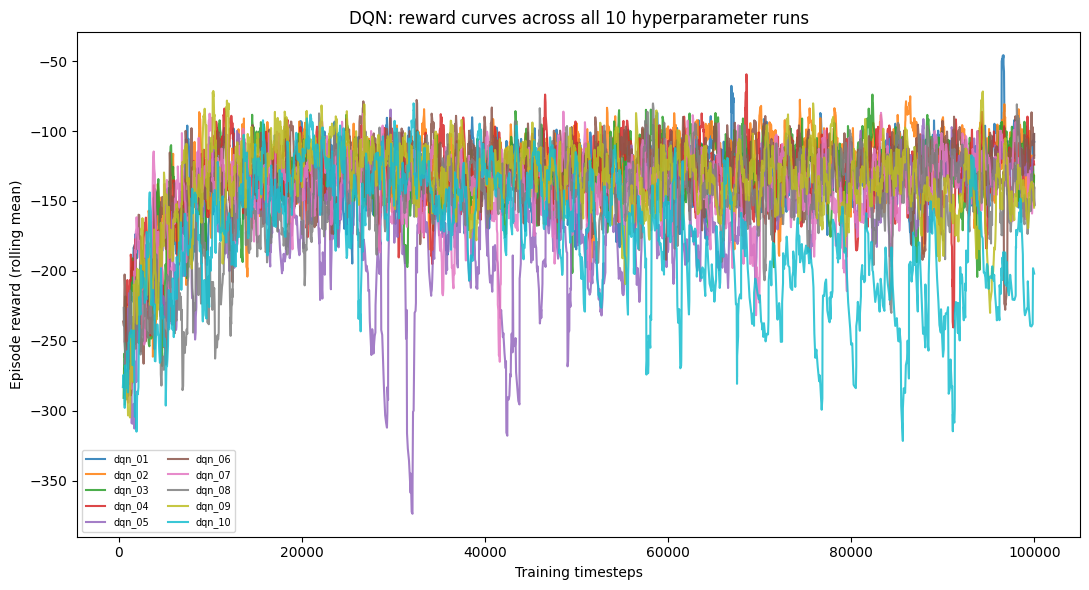

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
for run in all_runs:
    plt.plot(run["timesteps"], run["smoothed_reward"], label=run["run_id"], alpha=0.85)
plt.xlabel("Training timesteps")
plt.ylabel("Episode reward (rolling mean)")
plt.title(f"DQN: reward curves across all 10 hyperparameter runs")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/all_runs_reward_curves.png", dpi=150)
plt.show()

### DQN objective (loss) curve
Required plot: shows whether the Q-network's TD-error is actually decreasing (learning) or diverging (unstable hyperparameters).

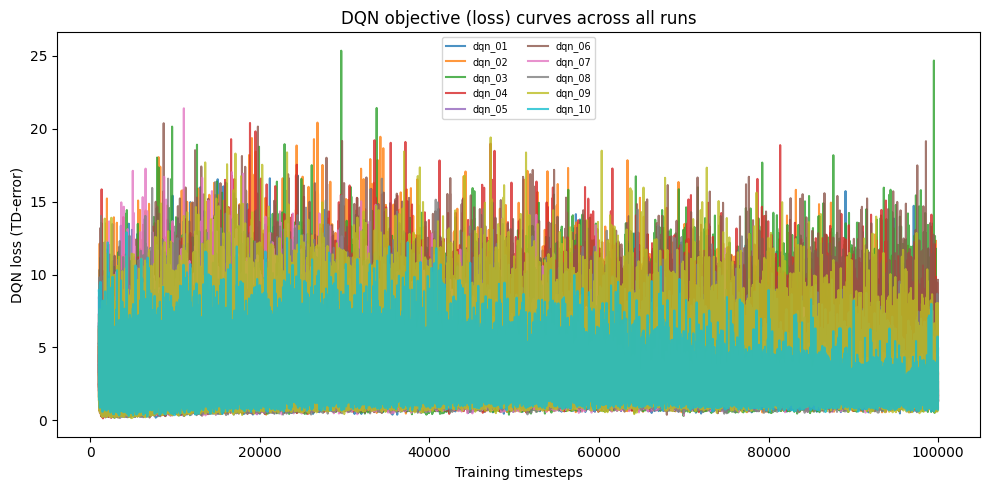

In [18]:
plt.figure(figsize=(10, 5))
for run in all_runs:
    if run["losses"]:
        plt.plot(run["loss_steps"], run["losses"], label=run["run_id"], alpha=0.8)
plt.xlabel("Training timesteps")
plt.ylabel("DQN loss (TD-error)")
plt.title("DQN objective (loss) curves across all runs")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/dqn_loss_curves.png", dpi=150)
plt.show()

## 9. Identify best run, evaluate thoroughly, and save as the official 'best model'

In [19]:
best_run_id = results_df.iloc[0]["run_id"]
print("Best run:", best_run_id)

best_model = DQN.load(f"{MODELS_DIR}/{best_run_id}")

def predict_fn(obs):
    action, _ = best_model.predict(obs, deterministic=True)
    return int(action)

metrics = evaluate_agent(predict_fn)
print(metrics)

import json
with open(f"{RESULTS_DIR}/best_model_metrics.json", "w") as f:
    json.dump({"best_run_id": str(best_run_id), **metrics}, f, indent=2)


Best run: dqn_03
Terminal event breakdown across 30 eval episodes: {'Battery depleted': 14, 'Entered no-fly zone': 7, 'Crashed into mountain': 9}
Milestone funnel (% of episodes reaching each stage):
  reached_hospital  : 0.0%
  picked_package    : 0.0%
  visited_charger   : 3.3%
  reached_clinic    : 6.7%
  delivered         : 0.0%
{'success_rate': np.float64(0.0), 'avg_reward': -110.26666666666667, 'reward_std': 35.15269864778836, 'avg_steps': 32.2, 'avg_battery_left': 38.45, 'avg_hazard_violations': 5.033333333333333, 'avg_path_efficiency': 1.0204954147338867, 'terminal_events': {'Battery depleted': 14, 'Entered no-fly zone': 7, 'Crashed into mountain': 9}, 'milestone_funnel': {'visited_charger': 3.3, 'reached_clinic': 6.7}}


### Emergency / robustness scenarios (Section 15.8)
Force a few hard starting conditions to see how the best agent copes.

In [20]:
def evaluate_scenario(predict_fn, n=15, low_battery=False, dense_hazards=False):
    env = MedicalDroneEnv()
    successes = []
    for seed in range(5000, 5000 + n):
        obs, info = env.reset(seed=seed)
        if low_battery:
            env.battery = 20.0
        if dense_hazards:
            # push existing no-fly zones closer to the direct hospital-clinic corridor
            mid = (env.hospital + env.clinic) / 2
            for i in range(len(env.no_fly_zones)):
                env.no_fly_zones[i] = mid + np.random.default_rng(seed).uniform(-2, 2, size=2)
        done = False
        success = False
        while not done:
            action = predict_fn(obs)
            obs, reward, term, trunc, info = env.step(action)
            if info["event"] == "Delivery successful":
                success = True
            done = term or trunc
        successes.append(success)
    env.close()
    return 100.0 * np.mean(successes)

scenario_results = {
    "low_battery": evaluate_scenario(predict_fn, low_battery=True),
    "dense_hazards": evaluate_scenario(predict_fn, dense_hazards=True),
    "standard": evaluate_scenario(predict_fn),
}
print(scenario_results)

with open(f"{RESULTS_DIR}/scenario_results.json", "w") as f:
    json.dump(scenario_results, f, indent=2)

{'low_battery': np.float64(0.0), 'dense_hazards': np.float64(0.0), 'standard': np.float64(0.0)}


## 10. Record a rollout video of the best agent (headless render, saved to Drive)

In [21]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
import imageio

env = MedicalDroneEnv(render_mode="rgb_array")
obs, info = env.reset(seed=2024)
frames = []
done = False
while not done:
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    action = predict_fn(obs)
    obs, reward, term, trunc, info = env.step(action)
    done = term or trunc
frame = env.render()
if frame is not None:
    frames.append(frame)
env.close()

video_path = f"{VIDEOS_DIR}/dqn_best_agent_rollout.mp4"
imageio.mimsave(video_path, frames, fps=30)
print("Saved rollout video to", video_path)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-p

Saved rollout video to /content/drive/MyDrive/student_name_rl_summative/assets/videos/dqn_best_agent_rollout.mp4


## 11. Discussion — what to look for in DQN

- If **exploration_fraction=0.30** (`dqn_08`) does noticeably better than the baseline, it suggests the
  environment's large randomized state space needs more exploration than DQN's defaults provide.
- Compare `dqn_06` (gamma=0.95) vs `dqn_07` (gamma=0.999): if the higher-gamma run has a much better success
  rate, that confirms the task genuinely requires long-horizon credit assignment (e.g. recharging *before*
  running low, not after).
- Check whether the small-buffer run (`dqn_03`) shows a noisier/less stable reward curve than the
  large-buffer run (`dqn_04`) — this isolates the effect of sample correlation on DQN stability.
- If the loss curve for any run explodes rather than decreasing, that run's learning_rate/target_update_interval
  combination is likely unstable and should be flagged in the report.